In [51]:
import pandas as pd
import numpy as np

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, KFold

from scipy.stats import ks_2samp

from xgboost import XGBClassifier

import shap

import matplotlib.pyplot as plt 

In [52]:
df =  pd.read_csv("datasets/kingametric_credit_risk.csv")

In [53]:
df.shape

(8744, 45)

In [67]:
df["emi_to_income"] = df["Total_EMI_per_month"] / df["Monthly_Inhand_Salary"]
df["debt_to_income"] = df["Outstanding_Debt"] / df["Annual_Income"]

df["Annual_Income"] = np.log1p(df["Annual_Income"])
df["Outstanding_Debt"] = np.log1p(df["Outstanding_Debt"])

In [68]:
df.shape

(8744, 47)

In [69]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

In [70]:
cat_cols = ["Payment_of_Min_Amount", "Credit_Mix", "Payment_Behaviour", "Borrower_Tier"]

df[cat_cols] = df[cat_cols].astype("category")

In [71]:
X = df.drop(columns=["Default_Flag"], axis=1)
y = df["Default_Flag"]

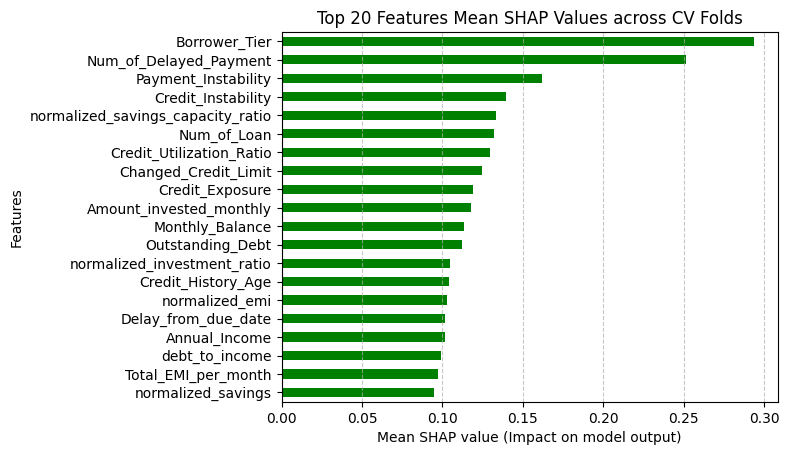

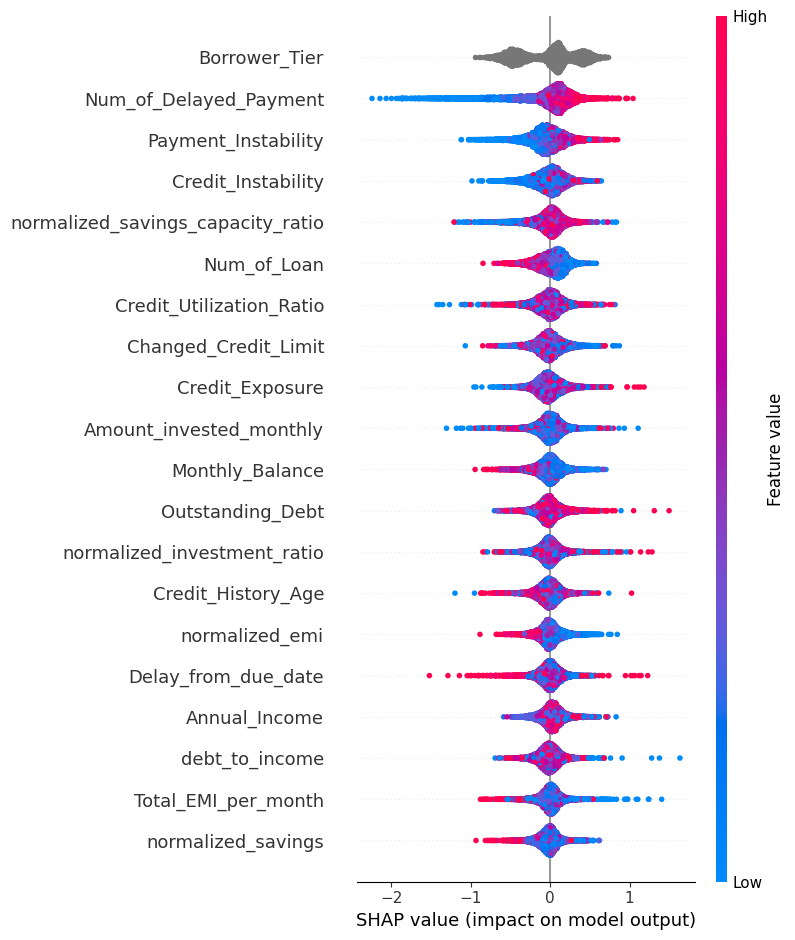

In [72]:
folds = KFold(n_splits=7, shuffle=True, random_state=42)
shap_values_list = []

for train_idx, val_idx in folds.split(X):

    xgb_m = XGBClassifier(enable_categorical=True, tree_method="hist").fit(X.iloc[train_idx], y.iloc[train_idx])

    explainer = shap.TreeExplainer(xgb_m)
    shap_fold = explainer.shap_values(X.iloc[val_idx])
    shap_values_list.append(shap_fold)

all_shap = np.vstack(shap_values_list)
mean_shap = np.abs(all_shap).mean(axis=0)

feature_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

#print("Top Features - Mean Absolute SHAP values:")
#print(feature_importance)

plt.Figure(figsize=(10, 6))
feature_importance.head(20).plot(kind="barh", color="green").invert_yaxis()
plt.title("Top 20 Features Mean SHAP Values across CV Folds")
plt.xlabel("Mean SHAP value (Impact on model output)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

shap.summary_plot(all_shap, X.iloc[np.concatenate([v for _, v in folds.split(X)])])

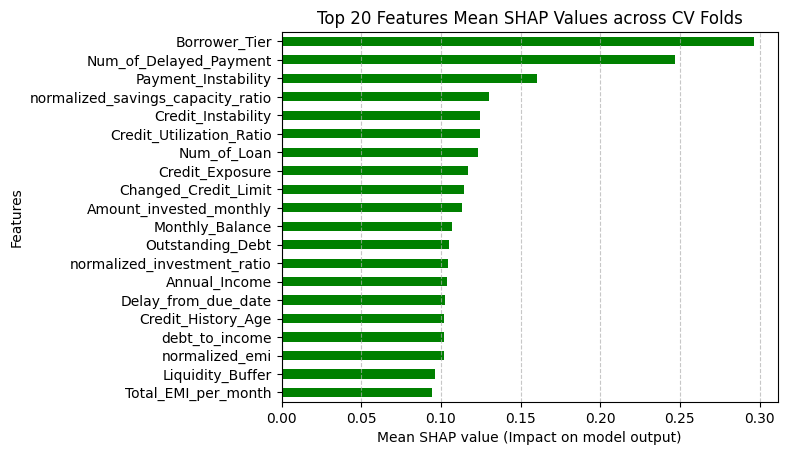

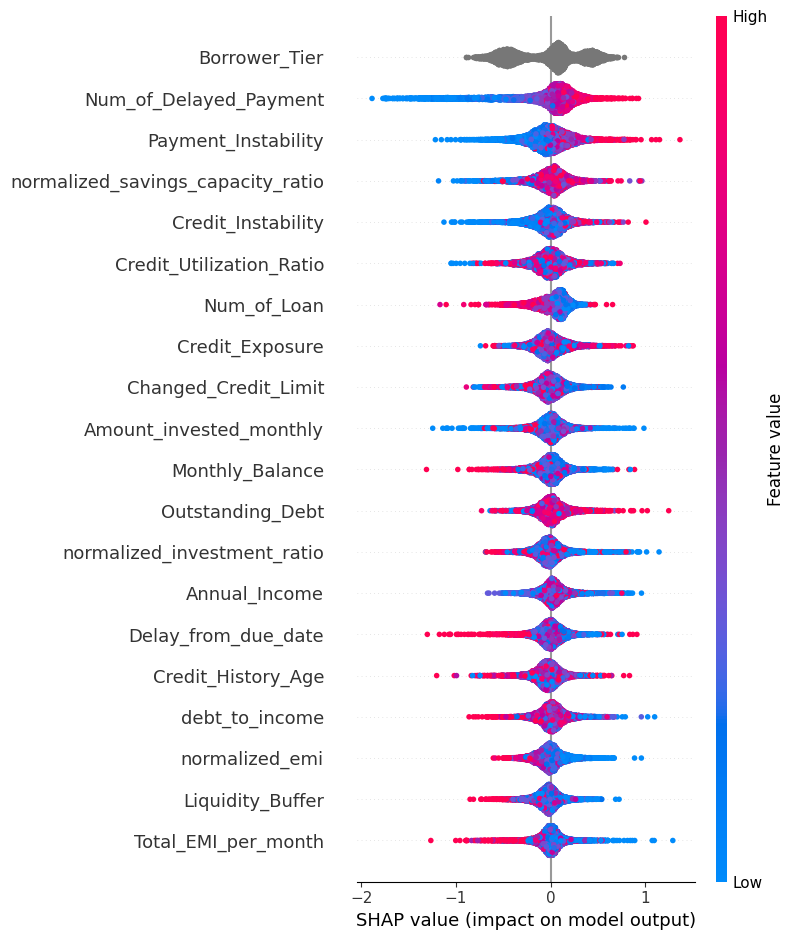

In [73]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
shap_values_list = []

for train_idx, val_idx in folds.split(X,y):

    xgb_m = XGBClassifier(enable_categorical=True, tree_method="hist").fit(X.iloc[train_idx], y.iloc[train_idx])

    explainer = shap.TreeExplainer(xgb_m)
    shap_fold = explainer.shap_values(X.iloc[val_idx])
    shap_values_list.append(shap_fold)

all_shap = np.vstack(shap_values_list)
mean_shap = np.abs(all_shap).mean(axis=0)

feature_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

#print("Top Features - Mean Absolute SHAP values:")
#print(feature_importance)

plt.Figure(figsize=(10, 6))
feature_importance.head(20).plot(kind="barh", color="green").invert_yaxis()
plt.title("Top 20 Features Mean SHAP Values across CV Folds")
plt.xlabel("Mean SHAP value (Impact on model output)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

shap.summary_plot(all_shap, X.iloc[np.concatenate([v for _, v in folds.split(X,y)])])

In [74]:
scale_pos_weight = len(y[y==0]) / len([y==1])

folds = KFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.6454664399603778, 0.6054793884175624, 0.6689427917620138, 0.6385102183666679, 0.629984352236551, 0.5938490927020532, 0.6220985385231079]
Mean AUC: 0.6291901174240477
KS per fold: [np.float64(0.23666223334495665), np.float64(0.18475224872103085), np.float64(0.26548893974065596), np.float64(0.21536312208108138), np.float64(0.19492556820566317), np.float64(0.14993888360722532), np.float64(0.19715708653247563)]
Mean KS: 0.2063268688904413


In [75]:
scale_pos_weight = len(y[y==0]) / len([y==1])

folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.6162323876844252, 0.623434936148962, 0.6038025255047442, 0.630995695702837, 0.6334183491474638, 0.6439145664499658, 0.6431101018196932]
Mean AUC: 0.6278440803511558
KS per fold: [np.float64(0.2118221927036387), np.float64(0.19230220446600557), np.float64(0.16748115383700746), np.float64(0.20217711826115906), np.float64(0.22022960214977053), np.float64(0.23904473535785317), np.float64(0.23162941193932376)]
Mean KS: 0.2092409169592512


In [76]:
select_features = feature_importance.head(20).index

X_ = X[select_features]

In [77]:
folds = KFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X_):

    X_train, X_val = X_.iloc[train_idx], X_.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.6440916987851053, 0.6132780516697733, 0.6671334858886346, 0.6518354045463413, 0.6261398586305509, 0.5859083903654583, 0.6282023537781994]
Mean AUC: 0.6309413205234377
KS per fold: [np.float64(0.2361684991405939), np.float64(0.1855913454000662), np.float64(0.26315484363081615), np.float64(0.22526306126430054), np.float64(0.19725474678801178), np.float64(0.14371800246827557), np.float64(0.19987845729700887)]
Mean KS: 0.20728985085558185


In [78]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X_, y):

    X_train, X_val = X_.iloc[train_idx], X_.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.6124519664120689, 0.6347173670067299, 0.6055043280778102, 0.6343264726165847, 0.6462286865948492, 0.6498619645560602, 0.6445809956362989]
Mean AUC: 0.6325245401286289
KS per fold: [np.float64(0.20232221642392903), np.float64(0.2127059998573161), np.float64(0.1800611162635847), np.float64(0.20438574588000286), np.float64(0.248186725642672), np.float64(0.23474040431026805), np.float64(0.23606138866625107)]
Mean KS: 0.21692337100628914
